# **Bioinformatics - LAB 01**
May-June 2026, "Machine learning in applications" course

*Prof. G. Urgese, V. Fra, B. Leto*

---
Within this notebook, techniques like PCA, t-SNE, and UMAP, mainly focused on data dimensionality reduction, are applied to the miRNA dataset.<br>
After a first general overview of the dataset, the individual contribution of all the principal components is shown by means of PCA, in order to qualitatively show the possible impact of dimensionality reduction. Then, 2D data clustering is performed. With t-SNE and UMAP data clustering only is instead addressed.
---

### Install and import the needed packages

In [5]:
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap

from mpl_toolkits.axes_grid1 import make_axes_locatable
import scipy.stats
from sklearn.model_selection import train_test_split
import pydot

In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import random
import csv

In [7]:
%%capture
! pip install gdown==4.3.1

### Useful functions

In [8]:
def extract_label(file_name, verbose=False):
    data = {}
    label = []
    with open(file_name, "r") as fin:
        reader = csv.reader(fin, delimiter=',')
        first = True
        for row in reader:
            lbl = row[2]
            if first or "TARGET" in lbl:
                first = False
                continue
            lbl = lbl.replace("TCGA-","")

            label.append(lbl)
            if lbl in data.keys():
                data[lbl] += 1
            else:
                data[lbl] = 1
    if verbose:
        print(f"Number of classes in the dataset = {len(data)}")
        pprint.pprint(data, indent=4)

    return label

In [9]:
def max_axis_tick(axis_var):

    if np.round(np.nanmax(axis_var),5) > 1:

        if len(str(int(np.nanmax(axis_var)))) > 2:

            max_tick = np.round(int(np.nanmax(axis_var)) + 10**(len(str(int(np.nanmax(axis_var))))-2), -len(str(int(np.nanmax(axis_var))))+2)

        elif len(str(int(np.nanmax(axis_var)))) == 2:

            max_tick = np.round(int(np.nanmax(axis_var)) + 10, -1)

        else:

            max_tick = int(np.nanmax(axis_var)) + 1

    else:

        max_tick = np.round(np.nanmax(axis_var), 2)

    return max_tick

In [10]:
def create_dictionary(labels):
    dictionary = {}
    class_names = np.unique(labels)
    for i, name in enumerate(class_names):
        dictionary[name] = i

    return dictionary

In [11]:
def label_processing(labels):
    new_miRna_label = []
    dictionary = create_dictionary(labels)
    for i in labels:
        new_miRna_label.append(dictionary[i])
    return new_miRna_label, dictionary

### Load the dataset

In [12]:
import os
mir_dataset = "https://drive.google.com/drive/folders/1oWWeord8YYvtxIo2Pq2peyx7xOI-1Tmb?usp=sharing"
if "MLinApp_course_data" not in os.listdir("./"):
  ! gdown $mir_dataset -O ./MLinApp_course_data --folder

Processing file 1p2I1VgW-0NDt9AHe0pZ6iwHB5RE5FXrv tcga_mir_label.csv
Processing file 1sqgFnNFD_IhtoQMHC_mqlupHPNqJA299 tcga_mir_rpm.csv
Building directory structure completed


Retrieving folder list
Retrieving folder list completed
Building directory structure
Downloading...
From: https://drive.google.com/uc?id=1p2I1VgW-0NDt9AHe0pZ6iwHB5RE5FXrv
To: c:\Users\dorot\OneDrive - Politecnico di Torino\Desktop\ML in Application\LABS\Labs-FP\notebooks\Bioinformatics and Neuromorphic\MLinApp_course_data\tcga_mir_label.csv

  0%|          | 0.00/3.99M [00:00<?, ?B/s]
100%|██████████| 3.99M/3.99M [00:00<00:00, 42.9MB/s]
Downloading...
From: https://drive.google.com/uc?id=1sqgFnNFD_IhtoQMHC_mqlupHPNqJA299
To: c:\Users\dorot\OneDrive - Politecnico di Torino\Desktop\ML in Application\LABS\Labs-FP\notebooks\Bioinformatics and Neuromorphic\MLinApp_course_data\tcga_mir_rpm.csv

  0%|          | 0.00/99.8M [00:00<?, ?B/s]
  3%|▎         | 3.15M/99.8M [00:00<00:03, 27.7MB/s]
 10%|▉         | 9.96M/99.8M [00:00<00:01, 48.3MB/s]
 16%|█▋        | 16.3M/99.8M [00:00<00:01, 53.6MB/s]
 23%|██▎       | 22.5M/99.8M [00:00<00:01, 56.7MB/s]
 29%|██▉       | 28.8M/99.8M [00:00<00:01, 58.

In [13]:
# Remove the first row and the last column from the feature
miRna_label = extract_label("./MLinApp_course_data/tcga_mir_label.csv")
miRna_data = np.genfromtxt('./MLinApp_course_data/tcga_mir_rpm.csv', delimiter=',')[1:,0:-1]

In [14]:
label_idx, dictionary = label_processing(miRna_label)
labels = np.unique(miRna_label, return_counts=True)

lab = []
for i in range(len(labels[0])):
  lab.append((labels[0][i], labels[1][i], dictionary[labels[0][i]]))

lab.sort(key= lambda x: x[1])

print(lab[-10:])




[('OV', 499, 19), ('LUSC', 523, 17), ('LGG', 530, 14), ('PRAD', 551, 22), ('LUAD', 567, 16), ('HNSC', 569, 9), ('THCA', 573, 28), ('UCEC', 579, 30), ('KIRC', 616, 11), ('BRCA', 1207, 2)]


In [15]:
# Deleting all the data that came from TARGET-* labels
number_to_delete = abs(len(miRna_label) - miRna_data.shape[0])
miRna_data = miRna_data[number_to_delete:,:]

In [16]:
# Z-score normalization
miRna_data = scipy.stats.zscore(miRna_data, axis=1)
assert np.isnan(miRna_data).sum() == 0

In [17]:
# Splitting dataset in train and test using 60% train and 20% validation 20%evaluation
train_data, val_data, train_label, val_label = train_test_split(miRna_data, miRna_label, test_size=0.20, random_state=42)
train_data, eva_data, train_label, eva_label = train_test_split(train_data, train_label, test_size=0.25, random_state=42)

In [18]:
n_classes = np.unique(train_label).size

print(n_classes)

33


### Inspect the dataset structure

In [19]:
print("Training set dimensions: {}".format(train_data.shape))
print("Validation set dimensions: {}".format(val_data.shape))
print("Test set dimensions: {}".format(eva_data.shape))

print("\n")

print("Dimensions of a single sample: {}".format(train_data[0].shape))

Training set dimensions: (6648, 1881)
Validation set dimensions: (2217, 1881)
Test set dimensions: (2217, 1881)


Dimensions of a single sample: (1881,)


### Single, random sample as an example

In [20]:
sample = random.randrange(len(train_data))

print(train_data[sample])
print(train_label[sample])


[ 1.82049218  1.80523672  1.8140613  ... -0.07257845  0.06693579
  2.19098196]
PRAD


### Dimensionality analysis and reduction using Principal Component Analysis

---

(PCA) on train_data

First, let's have a look at the cumulative explained variance taking into account all the components.

In [21]:
pca = PCA()

pca_train_data = pca.fit_transform(train_data)

exp_var_ratio = pca.explained_variance_ratio_
cumulative_exp_var_ratio = np.cumsum(exp_var_ratio)

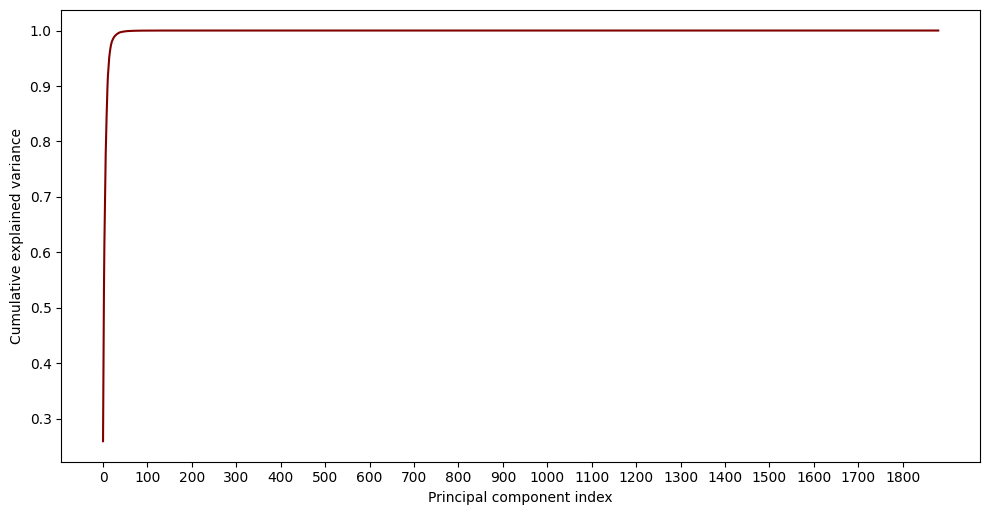

In [22]:
plt.figure(1, figsize=(10, 5.25))
plt.plot(cumulative_exp_var_ratio, color="maroon")
plt.xticks(range(train_data.shape[1])[::100])
plt.ylabel('Cumulative explained variance')
plt.xlabel('Principal component index')
plt.tight_layout()
plt.show()

#### How many components are needed to safely preserve 95% variance? How many for 99.9?

In [23]:
preserve_perc = 0.999
pca_reduced = PCA(n_components=preserve_perc)

pca_train_data_reduced = pca_reduced.fit_transform(train_data)

print("{}% variance with {} components out of {}".format(int(preserve_perc*100),pca_reduced.n_components_,pca.n_components_))

99% variance with 57 components out of 1881


#### Let's keep just the number of components ensuring that 95% variance is preserved. That is to say: *dimensionality reduction*

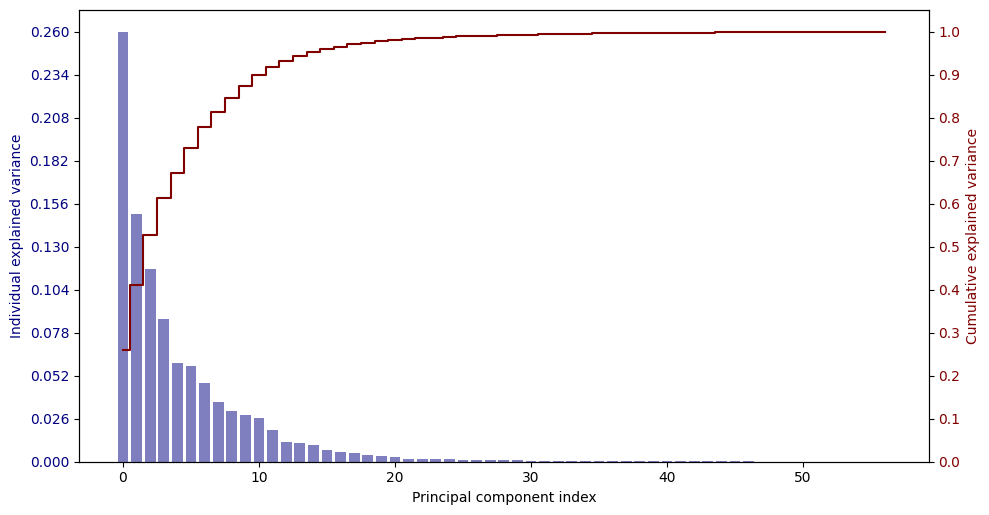

In [24]:
x = range(0,len(exp_var_ratio[:pca_reduced.n_components_]))
y1 = exp_var_ratio[:pca_reduced.n_components_]
y2 = cumulative_exp_var_ratio[:pca_reduced.n_components_]

fig, ax1 = plt.subplots(figsize=(10, 5.25))

color1 = 'navy'
ax1.set_xlabel('Principal component index')
ax1.set_ylabel('Individual explained variance', color=color1)
ax1.bar(x, y1, alpha=0.5, align='center', color=color1)
ax1.tick_params(axis='y', labelcolor=color1)

ax2 = ax1.twinx()
color2 = 'maroon'
ax2.set_ylabel('Cumulative explained variance', color=color2)
ax2.step(x, y2, where='mid', color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

ax1.set_facecolor('w')
ax1.grid(False)
ax2.grid(False)

lim_y1 = max_axis_tick(y1)
lim_y2 = max_axis_tick(y2)
ax1.set_yticks(np.linspace(0, lim_y1, 11))
ax2.set_yticks(np.linspace(0, lim_y2, 11))
ax1.set_ylim(0, lim_y1*1.05)
ax2.set_ylim(0, lim_y2*1.05)

fig.tight_layout()

plt.show()

#### What does the random sample in its reduced version look like compared to the original one?

In [25]:
print(f"Old sample: {train_data[sample]}, \nOld sample dimensions: {train_data[sample].shape}")
print(f"New sample: {pca_train_data_reduced[sample]}, \nNew sample dimensions: {pca_train_data_reduced[sample].shape}")

Old sample: [ 1.82049218  1.80523672  1.8140613  ... -0.07257845  0.06693579
  2.19098196], 
Old sample dimensions: (1881,)
New sample: [-5.41399740e+00  1.06460915e+01  2.44873414e-01  4.55888729e+00
  1.18523989e+01  9.25202975e+00 -1.00318772e+01  1.74072623e+01
 -5.54802136e+00  6.28472941e-01  9.20868189e+00  2.36058002e+00
  2.99213419e+00  3.40472715e-01 -1.58516558e+00 -2.09267809e+00
  3.75009125e+00  3.11743526e-01  5.45259083e-01 -5.01312785e-01
  4.48587341e-01  6.27123424e-02 -4.36062508e-01  5.74176244e-01
  4.97157347e-01  8.86741670e-04 -1.09969575e-01 -4.65560033e-01
 -7.74999532e-01 -6.05565732e-01 -8.33754444e-01 -4.18439843e-01
 -2.33989154e-01 -1.17786412e-01  2.16578853e-01 -8.14798890e-01
  1.72813340e-01 -2.78471521e-01 -5.84007301e-02 -2.90423486e-02
  3.99390717e-03  5.13355299e-02 -2.72552468e-02  4.64226025e-02
 -1.92278244e-01 -5.20107321e-02  1.00894271e-01 -2.00260891e-01
 -6.17867320e-02 -1.78924950e-01 -1.62863572e-02 -4.62952295e-03
  1.67095566e-01  6

#### Finally, let's use PCA for visualization of sample clustering in a 2D plane

To do so, only the first two components (namely those with the highest individual explained variance) are retained.

In [26]:
pca_plot = PCA(n_components=2)

pca_x_train_plot = pca_plot.fit_transform(train_data)

In [27]:
print(pca_x_train_plot.shape)

(6648, 2)


In [29]:
new_train_labels = label_processing(train_label)

In [30]:
print(len(new_train_labels))

2


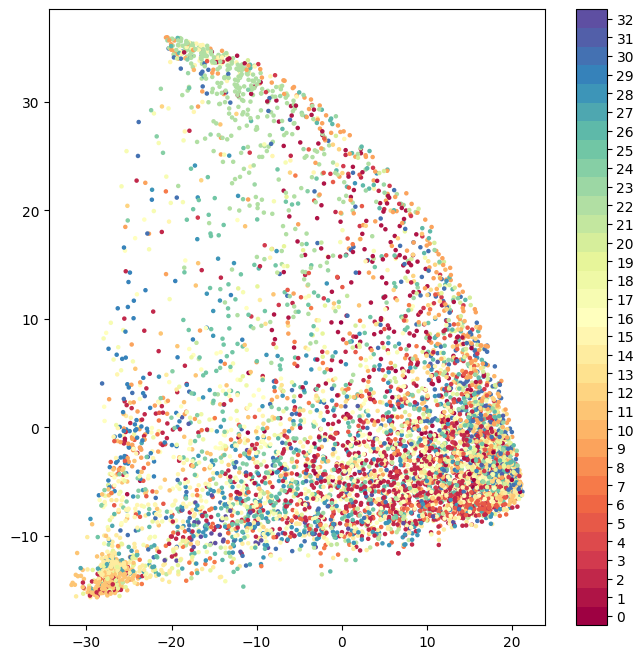

In [31]:
unique_labels = np.unique(new_train_labels[0])
n_labels = len(unique_labels)

plt.figure(1, figsize=(8, 8))
scatter = plt.scatter(pca_x_train_plot[:,0], pca_x_train_plot[:,1],
                      c=new_train_labels[0], s=5, cmap='Spectral')
plt.colorbar(scatter, boundaries=np.arange(n_labels + 1) - 0.5).set_ticks(np.arange(n_labels))
plt.show()

### Data clustering and visualization through t-Distributed Stochastic Neighbor Embedding (t-SNE) on train_data

In [32]:
tsne = TSNE(n_components=2,random_state=0)

tsne_x_train = tsne.fit_transform(train_data)

c:\Users\dorot\OneDrive - Politecnico di Torino\Desktop\ML in Application\LABS\Labs-FP\.venv\lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\dorot\OneDrive - Politecnico di Torino\Desktop\ML in Application\LABS\Labs-FP\.venv\lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "c:\Users\dorot\OneDrive - Politecnico di Torino\Desktop\ML in Application\LABS\Labs-FP\.venv\lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
  File "C:\Users\dorot\AppData\Local\Programs\Python\Pyt

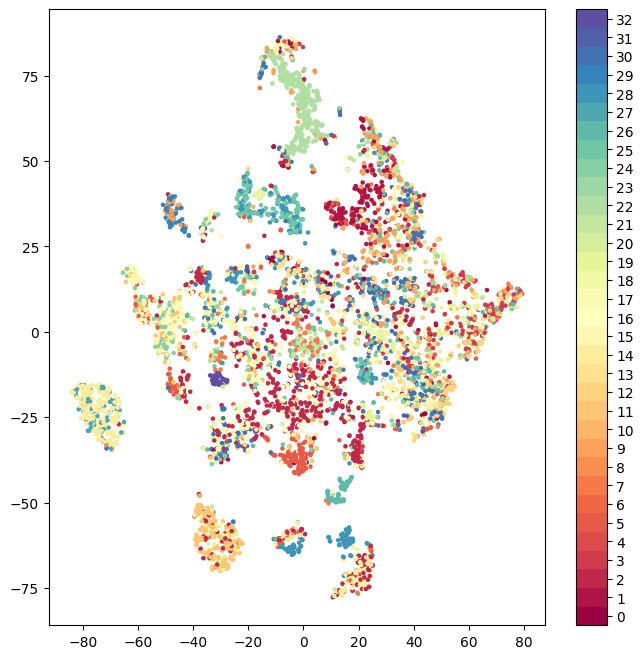

In [33]:
unique_labels = np.unique(new_train_labels[0])
n_labels = len(unique_labels)
plt.figure(1, figsize=(8, 8))
scatter = plt.scatter(tsne_x_train[:, 0], tsne_x_train[:, 1], c=new_train_labels[0], s=5, cmap='Spectral')
plt.colorbar(scatter, boundaries=np.arange(n_labels + 1) - 0.5).set_ticks(np.arange(n_labels))
plt.show()

### Data clustering and visualization through Uniform Manifold Approximation and Projection (UMAP) on train_data

In [35]:
reducer = umap.UMAP(random_state=42)

umap_x_train = reducer.fit_transform(train_data)

c:\Users\dorot\OneDrive - Politecnico di Torino\Desktop\ML in Application\LABS\Labs-FP\.venv\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


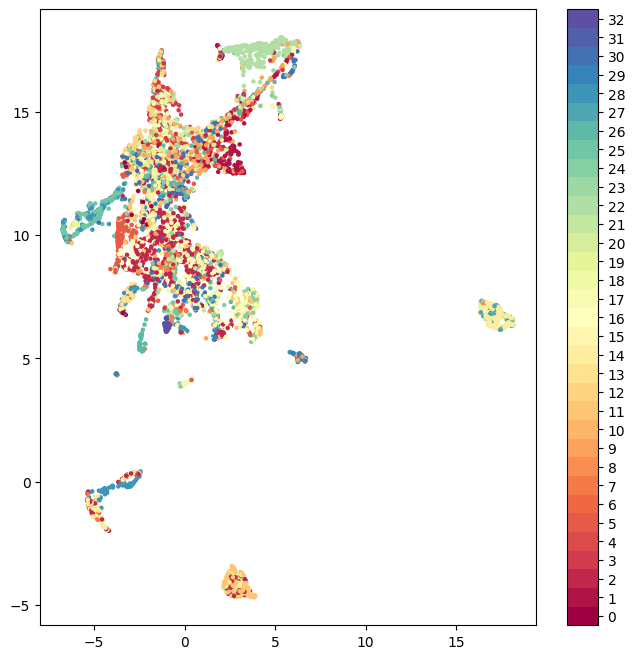

In [36]:
unique_labels = np.unique(new_train_labels[0])
n_labels = len(unique_labels)
plt.figure(1, figsize=(8, 8))
scatter = plt.scatter(umap_x_train[:, 0], umap_x_train[:, 1], c=new_train_labels[0], s=5, cmap='Spectral')
plt.colorbar(scatter, boundaries=np.arange(n_labels + 1) - 0.5).set_ticks(np.arange(n_labels))
plt.show()